Ogólne:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Wczytanie danych
df = pd.read_csv('../data/master_listings.csv', sep=';', low_memory=False)

# Konwersja kolumn numerycznych
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['price_per_meter'] = pd.to_numeric(df['price_per_meter'], errors='coerce')
df['rent'] = pd.to_numeric(df['rent'], errors='coerce')

# Filtrowanie - tylko aktywne oferty sprzedazy
active = df[(df['auction_type'] == 'sale') & 
            (df['price'].notna()) & 
            (df['price_per_meter'].notna()) &
            (df['price'] > 0)]

Cena za metr

Srednia: 16317 zl/m2
Mediana: 15800 zl/m2


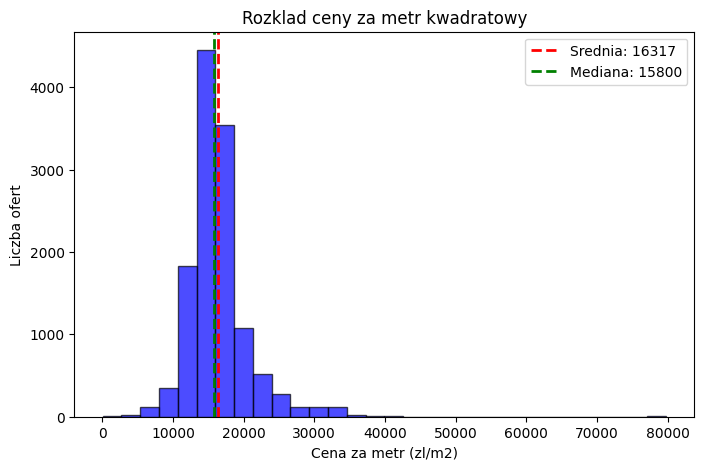

In [4]:
print(f"Srednia: {active['price_per_meter'].mean():.0f} zl/m2")
print(f"Mediana: {active['price_per_meter'].median():.0f} zl/m2")

plt.figure(figsize=(8, 5))
plt.hist(active['price_per_meter'].dropna(), bins=30, color='blue', edgecolor='black', alpha=0.7)
plt.axvline(active['price_per_meter'].mean(), color='red', linestyle='--', linewidth=2, label=f'Srednia: {active["price_per_meter"].mean():.0f}')
plt.axvline(active['price_per_meter'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {active["price_per_meter"].median():.0f}')
plt.xlabel('Cena za metr (zl/m2)')
plt.ylabel('Liczba ofert')
plt.title('Rozklad ceny za metr kwadratowy')
plt.legend()
plt.savefig('1_cena_za_metr.png', dpi=100)
plt.show()

Cena całkowita

Srednia: 998309 zl
Mediana: 825160 zl


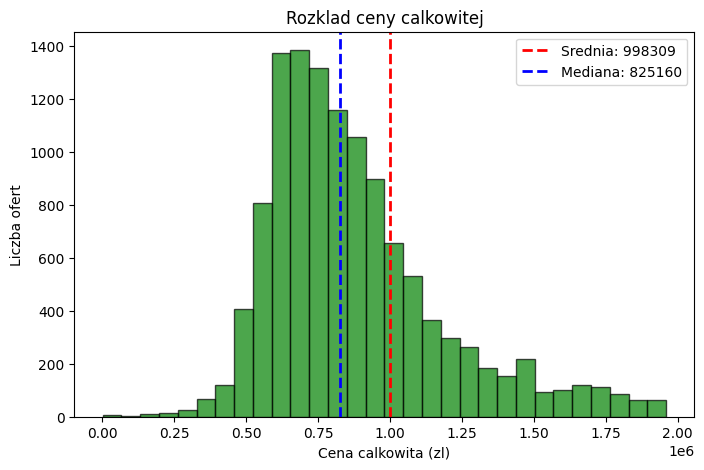

In [5]:
print(f"Srednia: {active['price'].mean():.0f} zl")
print(f"Mediana: {active['price'].median():.0f} zl")

# Odcięcie 5% najdrozszych dla lepszej czytelnosci
prices = active['price'].dropna()
prices_trimmed = prices[prices < prices.quantile(0.95)]

plt.figure(figsize=(8, 5))
plt.hist(prices_trimmed, bins=30, color='green', edgecolor='black', alpha=0.7)
plt.axvline(active['price'].mean(), color='red', linestyle='--', linewidth=2, label=f'Srednia: {active["price"].mean():.0f}')
plt.axvline(active['price'].median(), color='blue', linestyle='--', linewidth=2, label=f'Mediana: {active["price"].median():.0f}')
plt.xlabel('Cena calkowita (zl)')
plt.ylabel('Liczba ofert')
plt.title('Rozklad ceny calkowitej')
plt.legend()
plt.savefig('2_cena_calkowita.png', dpi=100)
plt.show()

Ilość aktywnych listingów

Laczna liczba: 12595


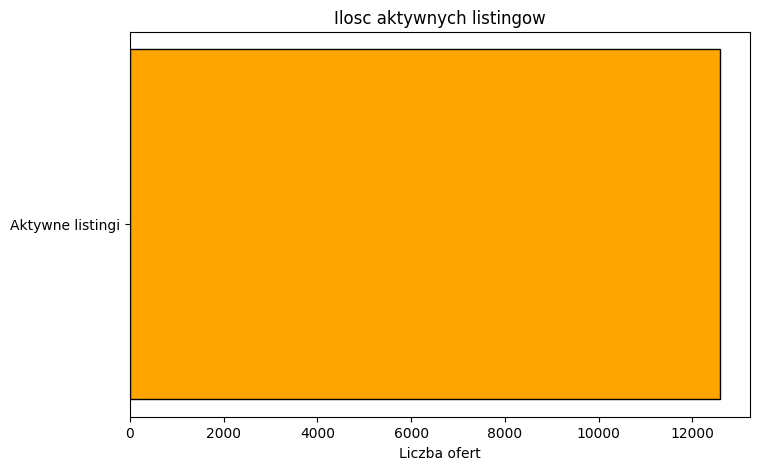

In [6]:
print(f"Laczna liczba: {len(active)}")

plt.figure(figsize=(8, 5))
plt.barh(['Aktywne listingi'], [len(active)], color='orange', edgecolor='black')
plt.xlabel('Liczba ofert')
plt.title('Ilosc aktywnych listingow')
plt.savefig('3_ilosc_listingow.png', dpi=100)
plt.show()

Koszt Administracyjny


Sredni koszt: 698 zl
Mediana kosztu: 620 zl


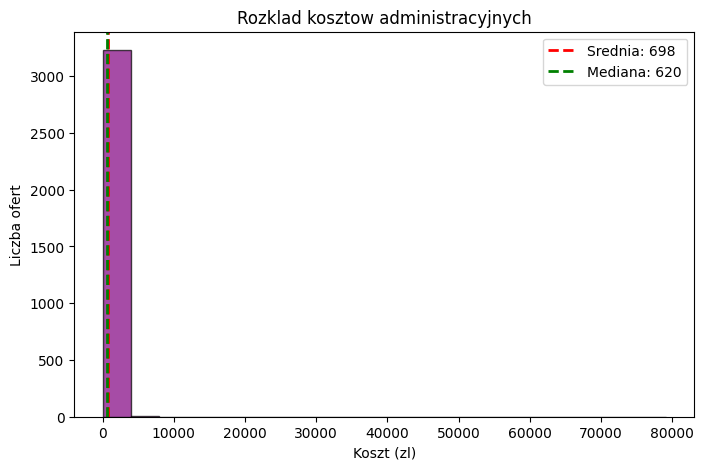

In [7]:
rent_data = df[df['rent'].notna() & (df['rent'] > 0)]
if len(rent_data) > 0:
    print(f"Sredni koszt: {rent_data['rent'].mean():.0f} zl")
    print(f"Mediana kosztu: {rent_data['rent'].median():.0f} zl")
    
    plt.figure(figsize=(8, 5))
    plt.hist(rent_data['rent'].dropna(), bins=20, color='purple', edgecolor='black', alpha=0.7)
    plt.axvline(rent_data['rent'].mean(), color='red', linestyle='--', linewidth=2, label=f'Srednia: {rent_data["rent"].mean():.0f}')
    plt.axvline(rent_data['rent'].median(), color='green', linestyle='--', linewidth=2, label=f'Mediana: {rent_data["rent"].median():.0f}')
    plt.xlabel('Koszt (zl)')
    plt.ylabel('Liczba ofert')
    plt.title('Rozklad kosztow administracyjnych')
    plt.legend()
    plt.savefig('4_koszt_administracyjny.png', dpi=100)
    plt.show()
else:
    print("Brak danych o kosztach administracyjnych")